# Cosmology with GWs/FRBs Associations (without redshift information)

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [2]:
import sys
sys.path.append('../Python_scripts')

__Importing modules and constants__

In [3]:
from config import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


__Importing useful support functions__

In [4]:
from support import *

__Importing cosmological functions__

In [5]:
from cosmo_support import *

-------------------------------------------------------------

# Table of Contents <a name="toc"></a>

1. [Basic definitions](#Definitions)
2. [Checking with Wei et al.](#Reproduction_Results_Wei_et_al)
3. [Cosmo inference without redshift - precise distance info](#Precise_distance_info)
4. [Cosmo inference without redshift - uncertain distance info](#Uncertain_distance_info)
5. [Finding the missing baryons with Macquart et al.](#Macquart_paper)

**Appendices**

AP1. [Checking cosmological functions](#AP_Cosmo_functions)

----------------------------------------------

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, we have $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

For the test cases, we assume the following **error estimates**:

- For the luminosity distance:

$$
\sigma_{d_L} = \sqrt{\left( \frac{2d_L}{\rho} \right)^2 + (0.05 z d_L)^2}.
$$

Since for the test cases we are not going to model any realistic GWs signals, we will either assume a signal-to-noise ratio $\rho = 8$, for all events (this is a conservative estimate), or we will assume a constant error (of 10%) on the luminosity distance of $\sigma_{d_L} \sim 0.1 d_L$.

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm HG}$ and potentially the source itself ${\rm DM}_{\rm HG}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm HG} \sim 30,
$$

and are combined to:

$$
\sigma_{\rm DM} = \sqrt{\sigma_{\rm MW}^2+\sigma_{\rm obs}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm HG}}{1+z}\right)^2},
$$

while a conservative estimate leads to a $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$.

**NB**: This formula seems to be error propagation + systematics. We observe one ${\rm DM} = {\rm DM}_{\rm obs}$, with a specific precision (systematic error), and we estimate the errors on the others (the error propagation formula wouldn't include the extra $\sigma_{\rm IGM}$).

Return to TOC [here](#toc).

-----------------------------------------

## 1. Reproduction of basic results <a name="Reproduction_Results_Wei_et_al"></a>

As a sanity check of our cosmological code, we start by a quick reproduction of the basic resutls of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]. 


<div class="alert alert-block alert-warning">
  <b>NB:</b> Our method is going to be simplified, i.e. we are going to use a simpler population model (for the test case) and just one repetition.
</div>


For this part, we put cosmological constraints, utilising the joint product $d_L \cdot {\rm DM}$. This method assumes **redshift information** from detecting the host of the FRB/GW. To put constraints we are following their $\chi^2$ approach:

$$
\chi^2 (\Omega_m, w) = \frac{[d_L^{\rm obs} \cdot {\rm DM}^{\rm obs}-d_L \cdot {\rm DM}(\Omega_m, w)]^2}{\sigma_{d_L{\rm DM}}^2},
$$

where we calculate the errors as:

$$
\sigma_{d_L \rm DM} = \sqrt{\left({\rm DM} \cdot \sigma_{d_L}\right)^2+ \left( d_L \cdot \sigma_{\rm DM} \right)^2 }.
$$

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. ${\rm DM}^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

Return to TOC [here](#toc).

## Get redshift

From Realistic_sources.ipynb

In [6]:
def Distribution_redshift(z, H0, Omega_m):
    Dc_squared = D_comoving(z, H0, Omega_m)**2
    rate = rate_function(z)
    Hz = Hubble_function(z, H0, Omega_m)
    
    return normalise(4*np.pi*Dc_squared*rate/(Hz*(1+z)))

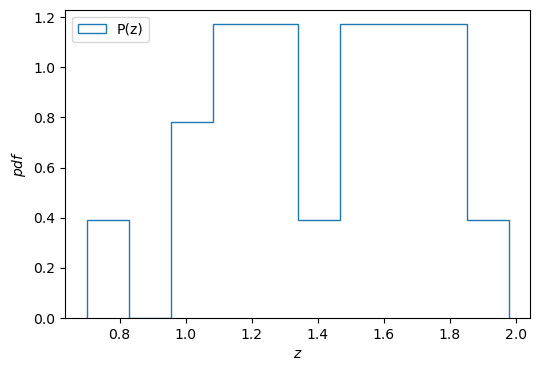

In [7]:
z_range = np.linspace(0.05, 2, 100)
z_obs = np.random.choice(z_range, size=20, replace=True,\
                            p=Distribution_redshift(z_range, HUBBLE, OMEGA_MATTER))

fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(z_obs, density=True, histtype='step', label='P(z)')
# ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

**For FRB DM, try to use Macquart pdf**

$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$

$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

$ p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) $

$ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

$\Delta=DM_{cosmic}/<DM_{cosmic}>$

$ \sigma_{DM}=Fz^{-0.5} $

Which 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$ in Macquart paper.

Better to consider Surajit's likelihood 3 ([Surajit](https://arxiv.org/abs/2410.01974)) later. They also consider $DM_{halo}$ as a gaussian distribution

$$ DM_{halo}=\frac{1}{\sqrt{2\pi}\sigma_{halo}}\exp\left(-\frac{(DM_{halo}-\mu_{halo})^2}{2\sigma_{halo}^2}\right) $$

Take median value found in Macquart paper MCMC:

$F=0.31$, $\exp(\mu)=68.2$, $\sigma_{host}=0.88$, $\Omega_b h_{70}=0.056$. And $DM_{MW,halo}=50 pc/cm^3$

In [8]:
from scipy.optimize import fsolve
from scipy import interpolate

def f_sigma_DM(F, z):
    return F/np.sqrt(z)

def pdf_DM_cosmo(Delta, C_0, A, sigma, alpha=3, beta=3):
    pdf=A*(Delta**(-beta))*np.exp(-((Delta**(-alpha)-C_0)**2)/(2*(alpha**2)*(sigma**2)))
    return pdf

def C0_sigma(sigma, alpha=3, beta=3):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    def objective_function(C_0):
        result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 0, np.inf)
        result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 0, np.inf)
        return result1-result2
    
    try:
        initial_guess=1.0
        solution = fsolve(objective_function, [initial_guess], full_output=True)
        
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
        else:
            print(f"find_C0 warning: sigma={sigma}")
            return None
            
    except Exception as e:
        print(f"find_C0 error, sigma={sigma}, error: {e}")
        return None
    
def find_C0(F, z, 
            sigmas, C0s #interpolation series
            , alpha=3, beta=3, 
            method="interpolation"):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    if (method=="interpolation"):
        sigma=f_sigma_DM(F,z)
        DM_sigma = interpolate.interp1d(sigmas, C0s, kind='cubic')
        C0 = DM_sigma(sigma)
        return C0
        
    else:
        print("Do accurate method")
    
        def objective_function(C_0):
            #return to_C_0(C_0[0], F, z, alpha) - 1
            A=1
            sigma=f_sigma_DM(F,z)
            result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, A, sigma, alpha, beta), 0, np.inf)
            result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, A, sigma, alpha, beta), 0, np.inf)
            return result1-result2
    
        try:
            initial_guess=1.0
            solution = fsolve(objective_function, [initial_guess], full_output=True)
        
            if solution[2] == 1:  # Check if solution is found
                return solution[0][0]
            else:
                print(f"find_C0 warning: F={F}, z={z}")
                return None
            
        except Exception as e:
            print(f"find_C0 error, F={F}, z={z}, error: {e}")
            return None
        
def find_A(C_0, F, z, alpha=3, beta=3):
    sigma=f_sigma_DM(F,z)
    pdf, error = quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 0, np.inf)
    # pdf, error = quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 1./400., 20.)
    # DM_mean=dispersion_measure(z=z, H0=HUBBLE, Om=OMEGA_MATTER)*(1+0.31*z/(1+z))
    # pdf, error = quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 1./400., 20.)
    
    # pdf = np.sum(pdf_DM_cosmo(DM_values/DM_mean, C_0, 1, sigma, alpha, beta))
    
    try:
        return 1/pdf
            
    except Exception as e:
        print(f"find_A error，pdf={pdf}, C_0={C_0}, F={F}, z={z}, error: {e}")
        return None

In [9]:
# Find sigma_IGM range

F = 0.31
# z_range = np.linspace(0.2, 2.0, 500)
# z_obs = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=20, method='rates')
print([F/np.sqrt(np.max(z_obs)),F/np.sqrt(np.min(z_obs))])

[0.22029055029517192, 0.37052086889366204]


Text(0, 0.5, 'sigmas')

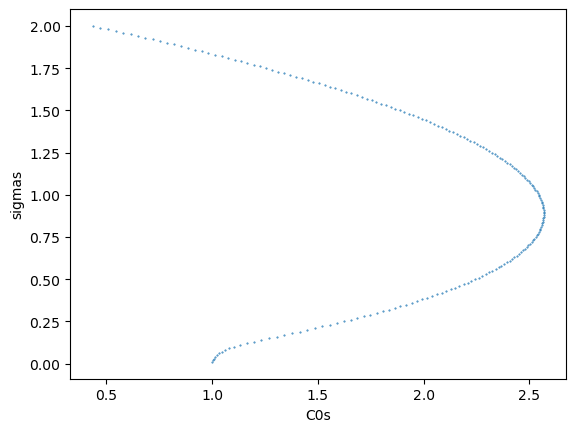

In [10]:
# interpolation preparation

sigmas=np.linspace(0.01, 2, 200)

C0s=np.zeros_like(sigmas)
for i, sigma in enumerate(sigmas):
    C0s[i]=C0_sigma(sigma)
    
plt.scatter(C0s,sigmas, s=0.2)
plt.xlabel('C0s')
plt.ylabel('sigmas')

In [11]:
# MCMC, maybe can use np.random.choice

def sample_delta(z, F=F, beta=3, alpha=3, n_burnin=500, sigmas=sigmas, C0s=C0s):
    # use Metropolis-Hastings to choose 1 sample for each z
    sigma = f_sigma_DM(F,z)
    C0=find_C0(F=F,z=z, sigmas=sigmas, C0s=C0s, method="interpolation")
    current_state = 1.0  # initial

    def log_target(delta):
        if delta <= 0:
            return -np.inf
        # Since in accept rate calculation no need A, ignore here
        return  -beta * np.log(delta)-(delta**(-alpha) - C0)**2 / (2 * (alpha**2) * (sigma**2))

    # Burn-in
    for _ in range(n_burnin):
        proposal = current_state + np.random.normal(0, 0.1)
        if proposal <= 0:
            continue
        log_accept = log_target(proposal) - log_target(current_state)
        if np.log(np.random.rand()) < log_accept:
            current_state = proposal
    return current_state

# For np.random.choice #have some problem
def DM_IGM_delta(z, F=F, alpha=3, beta=3):
    
    sigma = f_sigma_DM(F,z)
    C_0=find_C0(F=F,z=z, sigmas=sigmas, C0s=C0s, alpha=alpha, beta=beta, method="interpolation")
    A=find_A(F=F,C_0=C_0, z=z,alpha=alpha,beta=beta)
    
    # pdf=A*(Delta**(-beta))*np.exp(-((Delta**(-alpha)-C_0)**2)/(2*(alpha**2)*(sigma**2)))
    
    delta_range=np.linspace(1e-6, 1e6, 1000000)
    delta=np.random.choice(delta_range, size=1, replace=True,\
                            p=pdf_DM_cosmo(delta_range,C_0=C_0,A=A,sigma=sigma,alpha=alpha,beta=beta))
    return delta

For other component

In [12]:
DM_MW=50 # DM_MW,halo
# pdf_DM_host(DM, e_mu, sigma_host):

GW uncertainty, choose median here

In [13]:
# Find use quadratic function may get negative error in some large redshift

def GW_error_LVK(z, H0, Om, w=-1, order=1):
    if (order==1):
        a0=19.202
        a1=86.773
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=17.015
        a1=131.750
        a2=-174.911
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')
    
def GW_error_CE(z, H0, Om, w=-1, order=2):
    if (order==1):
        a0=9.792
        a1=9.704
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=7.649
        a1=18.581
        a2=-4.559
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')

In [14]:
dL_values_fid = np.zeros_like(z_range)
DM_values_fid = np.zeros_like(z_range)
dLDM_fid = np.zeros_like(z_range)

dL_values_obs = np.zeros_like(z_obs)
dL_values_obs_LVK = np.zeros_like(z_obs)
dL_values_obs_CE = np.zeros_like(z_obs)
DM_values_obs = np.zeros_like(z_obs)
s_dL_obs = np.zeros_like(z_obs)
s_dL_obs_LVK = np.zeros_like(z_obs)
s_dL_obs_CE = np.zeros_like(z_obs)
s_DM_obs = np.zeros_like(z_obs)

dLDM_obs = np.zeros_like(z_obs)
s_dLDM_obs = np.zeros_like(z_obs)

# obs values
for idx, z_val in enumerate(z_obs): 
    dL_fid = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    
    s_dL_obs[idx] = sigma_dL(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA, method='Wei')
    s_dL_obs_LVK[idx] = GW_error_LVK(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    s_dL_obs_CE[idx] = GW_error_CE(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    # s_DM_fid = SIGMA_DM
    
    dL_values_obs[idx] = np.random.normal(dL_fid, s_dL_obs[idx])
    dL_values_obs_LVK[idx] = np.random.normal(dL_fid, s_dL_obs_LVK[idx])
    dL_values_obs_CE[idx] = np.random.normal(dL_fid, s_dL_obs_CE[idx])
    # DM_values_obs[idx] = np.random.normal(DM_fid, s_DM_fid)
    
    # MCMC method
    delta = sample_delta(z_val)
    # np.choice method
    # delta = DM_IGM_delta(z=z_val)
    # Note delta is normalized DM_IGM
    s_DM_obs[idx] = DM_fid * f_sigma_DM(F=F, z=z_val) # May need to correct to the real function sigma. Not sure if DM_IGM in PDF is the sigma
    DM_values_obs[idx] = DM_fid * delta
    
    dLDM_obs[idx] = dL_values_obs[idx]*DM_values_obs[idx]
    # also need adjust later
    s_dLDM_obs[idx] = sigma_dLDM(dL_values_obs[idx], DM_values_obs[idx], s_dL_obs[idx])
    
# fid values
for idx, z_val in enumerate(z_range): 
    dL_values_fid[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)   
    dLDM_fid[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)

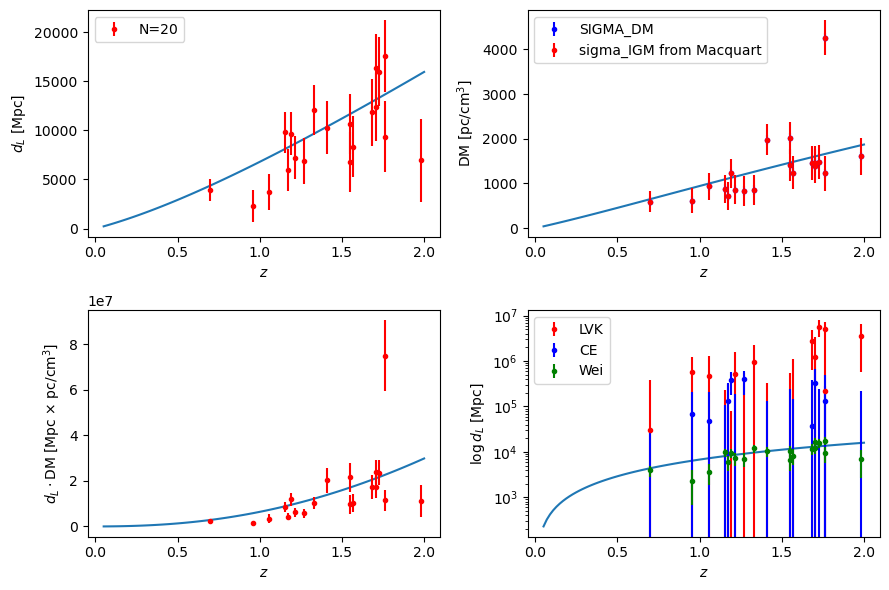

In [15]:
fig = plt.figure(figsize=(9,6))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

ax1.plot(z_range, dL_values_fid)
ax1.errorbar(z_obs, dL_values_obs, yerr=s_dL_obs, marker='o', ls='', ms=3, c='r', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(z_range, DM_values_fid)
ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='b',label='SIGMA_DM')
ax2.errorbar(z_obs, DM_values_obs, yerr=s_DM_obs, marker='o', ls='', ms=3, c='r',label='sigma_IGM from Macquart')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')
ax2.legend()

ax3.plot(z_range, dLDM_fid)
ax3.errorbar(z_obs, dLDM_obs, yerr=s_dLDM_obs, marker='o', ls='', ms=3, c='r')
ax3.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax3.set_xlabel(r'$z$')

ax4.plot(z_range, dL_values_fid)
ax4.errorbar(z_obs, dL_values_obs_LVK, yerr=s_dL_obs_LVK, marker='o', ls='', ms=3, c='r', label='LVK')
ax4.errorbar(z_obs, dL_values_obs_CE, yerr=s_dL_obs_CE, marker='o', ls='', ms=3, c='b', label='CE')
ax4.errorbar(z_obs, dL_values_obs, yerr=s_dL_obs, marker='o', ls='', ms=3, c='g', label='Wei')
ax4.set_ylabel(r'$\log d_{L}$ [Mpc]')
ax4.set_xlabel(r'$z$')
ax4.legend(loc='upper left')
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

*Cosmological constraints*

In [16]:
### We create a grid of values for Om and Ho
Omega_m_array = np.linspace(0.0, 0.6, 100)
w_array = np.linspace(-3.0, 0.0, 140)

Om_, w_ = np.meshgrid(Omega_m_array, w_array)

In [17]:
### Fitting Om        
chi_fit = np.zeros_like(Omega_m_array)

for idx_Om, Om in enumerate(Omega_m_array):
    chi_square = 0
    for idx_z, z_val in enumerate(z_obs):
        dLDM = dLDM_measure(z_val, HUBBLE, Om, w=W_LAMBDA)        
            
        chi_square += (dLDM_obs[idx_z]-dLDM)**2/s_dLDM_obs[idx_z]**2  # For all events, add in χ^2
       
    chi_fit[idx_Om] = chi_square

In [18]:
### Finding the best-fit Om & error 
### See P. Gregory, p.260

## Find Om value
chi_1D_min = np.min(chi_fit)
id_Om_min = np.where(chi_fit==chi_1D_min)[0][0]

## Find sigma
sigma1_chi_fit = chi_1D_min+1
delta_chi = np.abs(chi_fit-sigma1_chi_fit)
delta_chi_min = np.min(delta_chi)
id_Om_sigma_1 = np.where(delta_chi==delta_chi_min)[0][0] # find id_Om when χ^2 differences==1

## Transform to the physical parameter of interest
Omega_fit = Omega_m_array[id_Om_min]
sigma_Om = np.abs(Omega_m_array[id_Om_min]-Omega_m_array[id_Om_sigma_1])
# This is how to consider 1 sigma for mock events?

In [19]:
### Fitting Om & w
chi_fit_2D = np.zeros_like(Om_)

for idx_Om, Om in enumerate(Omega_m_array):
    for idx_w, w_val in enumerate(w_array):
        chi_square = 0
        for idx_z, z_val in enumerate(z_obs):
            dLDM = dLDM_measure(z_val, HUBBLE, Om, w=w_val)        
            
            chi_square += (dLDM_obs[idx_z]-dLDM)**2/s_dLDM_obs[idx_z]**2
    
        chi_fit_2D[idx_w, idx_Om] = chi_square     

For marginalisation of $\chi^2$, check [[Slides](http://astronomy.swin.edu.au/~cblake/StatsLecture3.pdf)] & [[YT video](https://youtu.be/TSNV-4K3Fws?t=1395)]. 

The probability of drawing a sample of data given a model is related to the $\chi^2$ value by the likelihood:

$$
\mathcal{L} (I|m) \sim e^{-\chi^2/2},
$$

i.e. minimising $\chi^2$ is equivalent of maximising the likelihood.

**NB:** $\chi^2$ assumes that the data values are normally distributed around the model (consistent with our mock data generation).

The process of marginalisation is the following:

1. From the $\chi^2$ values, we calculate the likelihood: $\mathcal{L} \sim e^{-\chi^2/2}$.
2. Normalise $\mathcal{L}$ to calculate probability in the grid (for 2 variables): $\Sigma_{a, b} \mathcal{L}_{2D}(a, b) = 1, \rightarrow P_{2D}(a, b)$.
3. Get the marginalised probability by summing over the parameter of non-interest: $P_{1D}(a) = \Sigma_b P_{2D}(a, b)$.

In [20]:
### Finding the best-fit Om & error [by marginalizing over w of the 2D model]

P2d = np.exp(-chi_fit_2D/2)  # Finding the pdf
P2d /= np.sum(P2d)  # Normalizing the pdf
P_Om = np.sum(P2d, axis=0)  # Marginalizing to get the parameter of interest

### Comparing (the same method) with numerical integration
### This doesn't change things - it's just a different normalization constant
P2d_int = np.exp(-chi_fit_2D/2)
P2d_norm = np.trapz(np.trapz(P2d_int, x=w_array, axis=0), x=Omega_m_array)

P2d_prob = P2d_int/P2d_norm

P1d_Om = np.trapz(P2d_prob, x=w_array, axis=0)
P1d_Om /= np.trapz(P1d_Om, x=Omega_m_array)

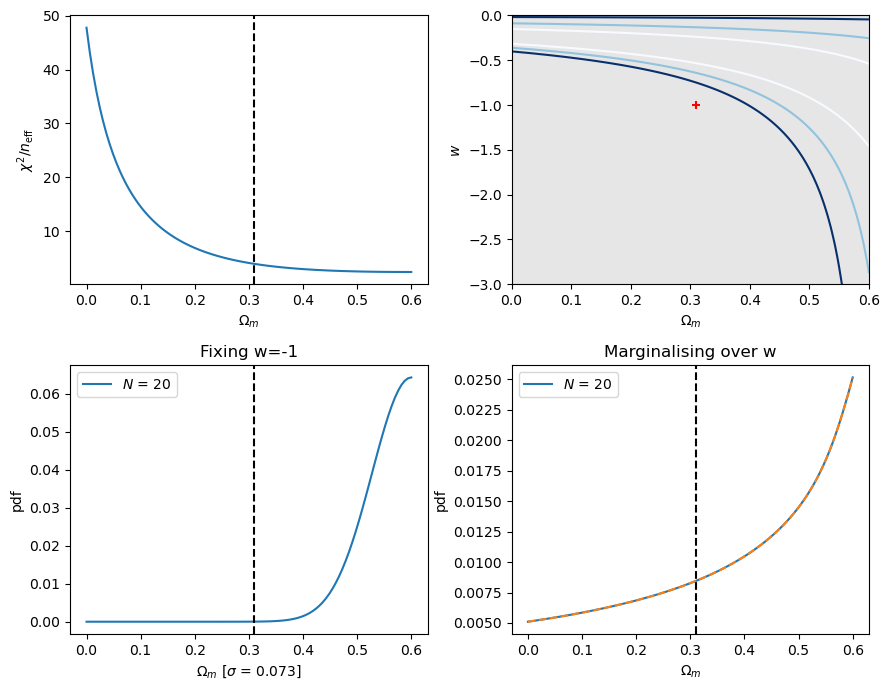

In [21]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)


ax1.plot(Omega_m_array, chi_fit/(len(z_obs)-1))
ax1.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax1.set_xlabel(r'$\Omega_m$')
ax1.set_ylabel(r'$\chi^2/n_{\rm eff}$') # chi^2/(n-1) for real data?


chi_2D_min = np.min(chi_fit_2D)
ax2.contour(Om_, w_, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax2.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='r', zorder=10)
ax2.set_xlabel(r'$\Omega_m$')
ax2.set_ylabel(r'$w$')
ax2.set_facecolor('0.9')

ax3.plot(Omega_m_array, normalise(Gaussian(Omega_m_array, Omega_fit, sigma_Om)),\
         label=fr'$N$ = {len(z_obs)}')
ax3.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax3.set_xlabel(fr'$\Omega_m$ [$\sigma$ = {round(sigma_Om, 3)}]')
ax3.set_ylabel('pdf')
ax3.legend()
ax3.set_title('Fixing w=-1')

ax4.plot(Omega_m_array, normalise(P_Om),\
         label=fr'$N$ = {len(z_obs)}')
ax4.plot(Omega_m_array, normalise(P1d_Om), ls='--')
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(fr'$\Omega_m$')
ax4.set_ylabel('pdf')
ax4.legend()
ax4.set_title('Marginalising over w')



plt.tight_layout()
plt.show()

**NB**: Compare with Figures 3 & 4 of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]. Variations are possible and are the result of the data generation process.

------------------------------------------

## 2. Cosmological inference without redshift information (proof of concept) <a name="Precise_distance_info"></a>

The method above assumes determination of the redshift of the GWs/FRB source. This limits the analyses to very well localised events. We develop below a method to infer cosmological parameters without any redshift knowledge.

#### 2.1. Ideal luminosity distances

When we do not have redshift information, we can use $d_L$ (luminosity distance) from GWs and ${\rm DM}_{\rm IGM}$ from the FRBs to put constraints on the cosmological parameters ($H_0, \Omega_m, w$).

In this simplified case, we assume idealised $d_L$, i.e. precise determination of distances (from the GWs). Then, we can calculate:

$$
d_L^{\rm obs}\quad \underrightarrow{(H_0, \Omega_m, w)}\quad z \quad \underrightarrow{(H_0, \Omega_m, w)}\quad {\rm DM},
$$

which can then be compared to ${\rm DM}^{\rm obs}$, with the standard $\chi^2$ statistic


$$
\chi^2 (H_0, \Omega_m, w) = \frac{[{\rm DM}^{\rm obs}-{\rm DM}(H_0, \Omega_m, w)]^2}{\sigma_{{\rm DM}}^2},
$$

where for $\sigma_{{\rm DM}}$ we assume a value of $\sigma_{{\rm DM}} \sim 105$ pc/cm$^3$ (as above).

Return to TOC [here](#toc).

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. 

The mock obsersations are based on these, but with scatter that follows a guassian distribution, e.g. $DM^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

For the observed luminosity distances, we **then assume zero errors**, i.e. $\sigma_{d_L} \rightarrow 0$. We do this step now (after creating the scattered values), so that the original $d_L^{\rm obs}$ will follow a more realistic distribution, i.e. not fall exactly on the fiducial cosmology expectation.

We then use the luminosity distances to infer redshifts as an intermediate step and then dispersion measures, as detailed above.

With these we calculate the $\chi^2$ statistic and constrain cosmology.

In [22]:
### Create a redshift range
z_range = np.linspace(0.2, 2.0, 500)

### Sample the obervations
z_obs = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=20, method='rates')

dL_values_fid = np.zeros_like(z_range)
DM_values_fid = np.zeros_like(z_range)
dLDM_fid = np.zeros_like(z_range)

dL_values_obs = np.zeros_like(z_obs)
DM_values_obs = np.zeros_like(z_obs)
s_dL_obs = np.zeros_like(z_obs)


### Create mock observations (following the fiducial cosmology + scatter)
for idx, z_val in enumerate(z_obs): 
    dL_fid = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_fid = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    
    s_dL_obs[idx] = sigma_dL(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA, method='Wei')
    s_DM_fid = SIGMA_DM
    
    dL_values_obs[idx] = np.random.normal(dL_fid, s_dL_obs[idx])
    DM_values_obs[idx] = np.random.normal(DM_fid, s_DM_fid)
    
### Create the fiducial cosmo values (with zero scatter) for comparison    
for idx, z_val in enumerate(z_range): 
    dL_values_fid[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)
    DM_values_fid[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=W_LAMBDA)   

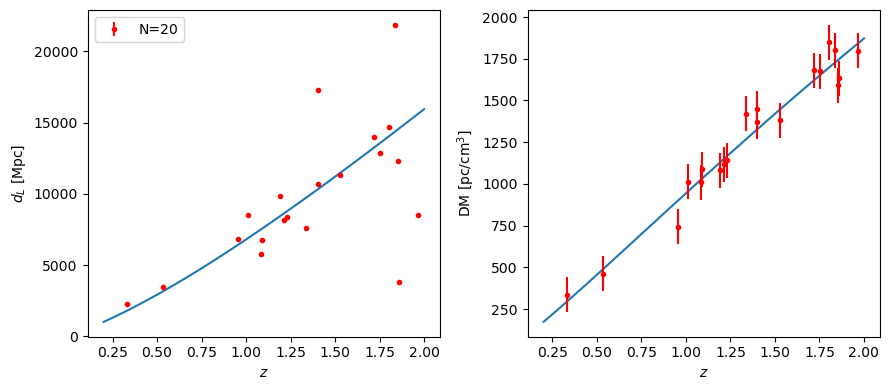

In [23]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_range, dL_values_fid)
ax1.errorbar(z_obs, dL_values_obs, yerr=0, marker='o', ls='', ms=3, c='r', label=f'N={len(z_obs)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(z_range, DM_values_fid)
ax2.errorbar(z_obs, DM_values_obs, yerr=SIGMA_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

*Cosmological constraints*

We infer:

- $H_0$ with $\Omega_m, w$ fixed to their fiducial values
- $H_0, \Omega_m$ with $w$ fixed to its fiducial value
- $H_0, \Omega_m, w$

In [24]:
H0_array = np.linspace(10, 140, 50)
Omega_m_array = np.linspace(0.1, 0.5, 40)
w_array = np.linspace(-3.0, 0.0, 45)

H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

H3D_, Om3D_, w3D_ = np.meshgrid(H0_array, Omega_m_array, w_array)

1 & 2 parameter fit

In [25]:
### Fitting only H0
chi_fit = np.zeros_like(H0_array)

for idx_h, H0 in enumerate(H0_array):
    chi_square = 0
    for idx_z, z_val in enumerate(z_obs):
        DM = dispersion_measure(z_val, H0, OMEGA_MATTER, w=W_LAMBDA)
        
        chi_square += (DM_values_obs[idx_z]-DM)**2/SIGMA_DM**2  # For all events, add in χ^2
    
    chi_fit[idx_h] = chi_square    

In [26]:
## Find H0 value
chi_1D_min = np.min(chi_fit)
id_H0_min = np.where(chi_fit==chi_1D_min)[0][0]

## Find sigma
sigma1_chi_fit = chi_1D_min+1
delta_chi = np.abs(chi_fit-sigma1_chi_fit)
delta_chi_min = np.min(delta_chi)
id_H0_sigma_1 = np.where(delta_chi==delta_chi_min)[0][0]

## Transform to the physical parameter of interest
H0_fit = H0_array[id_H0_min]
sigma_H0 = np.abs(H0_array[id_H0_min]-H0_array[id_H0_sigma_1])

if sigma_H0==0:
    print("Higher resolution is needed in the H0 grid")

Higher resolution is needed in the H0 grid


In [27]:
### Fitting H0 & Om
chi_fit_2D = np.zeros_like(H_Om)

for idx_h, H0 in enumerate(H0_array):
    for idx_Om, Om in enumerate(Omega_m_array):
        chi_square = 0
        for idx_z, z_val in enumerate(z_obs):
            DM = dispersion_measure(z_val, H0, Om, w=W_LAMBDA)
        
            chi_square += (DM_values_obs[idx_z]-DM)**2/SIGMA_DM**2
    
        chi_fit_2D[idx_Om, idx_h] = chi_square

In [28]:
### Finding the best-fit H0 & error [by marginalising over Om of the 2D model]

P2d = normalise(np.exp(-chi_fit_2D/2))
P_H0 = np.sum(P2d, axis=0)

/mnt/d/Document/Research/FRB/cosmology/FRB_GW_association_cosmo/Notebooks/../Python_scripts/support.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(s0*np.sqrt(2*np.pi))*np.exp(-0.5*(x-x0)**2/s0**2)
/mnt/d/Document/Research/FRB/cosmology/FRB_GW_association_cosmo/Notebooks/../Python_scripts/support.py:32: RuntimeWarning: divide by zero encountered in divide
  return 1/(s0*np.sqrt(2*np.pi))*np.exp(-0.5*(x-x0)**2/s0**2)
/mnt/d/Document/Research/FRB/cosmology/FRB_GW_association_cosmo/Notebooks/../Python_scripts/support.py:32: RuntimeWarning: invalid value encountered in divide
  return 1/(s0*np.sqrt(2*np.pi))*np.exp(-0.5*(x-x0)**2/s0**2)
/mnt/d/Document/Research/FRB/cosmology/FRB_GW_association_cosmo/Notebooks/../Python_scripts/support.py:32: RuntimeWarning: invalid value encountered in multiply
  return 1/(s0*np.sqrt(2*np.pi))*np.exp(-0.5*(x-x0)**2/s0**2)


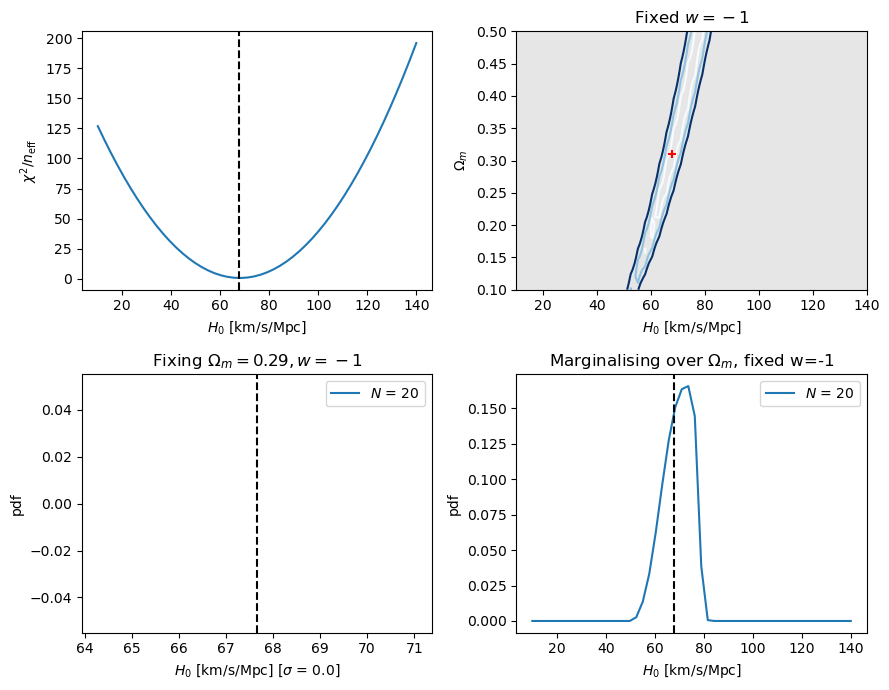

In [29]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)


ax1.plot(H0_array, chi_fit/(len(z_obs)-1))
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_ylabel(r'$\chi^2/n_{\rm eff}$')


chi_2D_min = np.min(chi_fit_2D)
ax2.contour(H_Om, Om_H0, chi_fit_2D, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax2.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax2.set_ylabel(r'$\Omega_m$')
ax2.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax2.set_facecolor('0.9')
ax2.set_title(r'Fixed $w=-1$')

ax3.plot(H0_array, normalise(Gaussian(H0_array, H0_fit, sigma_H0)),\
         label=fr'$N$ = {len(z_obs)}')
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(fr'$H_0$ [km/s/Mpc] [$\sigma$ = {round(sigma_H0, 3)}]')
ax3.set_ylabel('pdf')
ax3.legend()
ax3.set_title(r'Fixing $\Omega_m = 0.29, w=-1$')


ax4.plot(H0_array, normalise(P_H0),\
         label=fr'$N$ = {len(z_obs)}')
ax4.axvline(x=HUBBLE, ls='--', c='black')
ax4.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax4.set_ylabel('pdf')
ax4.legend()
ax4.set_title(r'Marginalising over $\Omega_m$, fixed w=-1')


plt.tight_layout()
plt.show()

3 parameter fit (this takes more time, if the grid is high-resolution)

In [30]:
### Fitting H0 & Om & w
chi_fit_3D = np.zeros_like(H3D_)

for idx_h, H0 in enumerate(H0_array):
    for idx_Om, Om in enumerate(Omega_m_array):
        for idx_w, W in enumerate(w_array):
            chi_square = 0
            for idx_z, z_val in enumerate(z_obs):
                DM = dispersion_measure(z_val, H0, Om, w=W)
        
                chi_square += (DM_values_obs[idx_z]-DM)**2/SIGMA_DM**2
    
            chi_fit_3D[idx_Om, idx_h, idx_w] = chi_square

In [31]:
### In this part, we fix one of the three cosmological variables to their default value, 
### and plot the remaining 2D constraints (of the other two variables).

index_W_LAMBDA = np.where(np.abs(w_array-W_LAMBDA)==np.min(np.abs(w_array-W_LAMBDA)))[0][0]
chi_2D_H0Om = chi_fit_3D[:, :, index_W_LAMBDA]

index_OMEGA_MATTER = np.where(np.abs(Omega_m_array-OMEGA_MATTER)==np.min(np.abs(Omega_m_array-OMEGA_MATTER)))[0][0]
chi_2D_H0w = chi_fit_3D[index_OMEGA_MATTER, :, :]

index_HUBBLE = np.where(np.abs(H0_array-HUBBLE)==np.min(np.abs(H0_array-HUBBLE)))[0][0]
chi_2D_Omw = chi_fit_3D[:, index_HUBBLE, :]

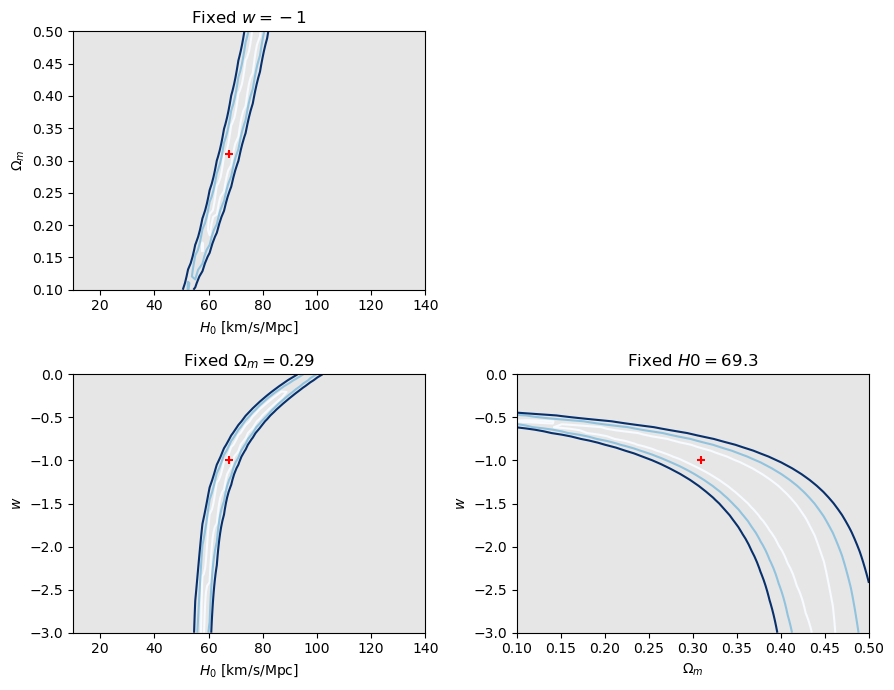

In [32]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)


chi_2D_min = np.min(chi_2D_H0Om)
ax1.contour(H_Om, Om_H0, chi_2D_H0Om, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_facecolor('0.9')
ax1.set_title(r'Fixed $w=-1$')

chi_2D_min = np.min(chi_2D_H0w)
ax3.contour(H_w, w_H, chi_2D_H0w.T, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax3.scatter(HUBBLE, W_LAMBDA, marker='+', c='r', zorder=10)
ax3.set_ylabel(r'$w$')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_facecolor('0.9')
ax3.set_title(r'Fixed $\Omega_m=0.29$')

chi_2D_min = np.min(chi_2D_Omw)
ax4.contour(Om_w, w_Om, chi_2D_Omw.T, levels=[chi_2D_min+2.3, chi_2D_min+6.17, chi_2D_min+11.8], cmap='Blues')
ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='r', zorder=10)
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel(r'$w$')
ax4.set_facecolor('0.9')
ax4.set_title(r'Fixed $H0=69.3$')


plt.tight_layout()
plt.show()

In [33]:
### Finding the best-fit H0 & Om & w [by marginalising over parameters of the 3D model]

## The detailed integration is not needed. It introduces some extra constant terms
## that are absorbed in the normalisation procedure in any case.

P3d = np.exp(-chi_fit_3D/2)
P3d_norm = np.sum(P3d) #np.trapz(np.trapz(np.trapz(P3d, x=w_array, axis=2), x=Omega_m_array, axis=0), x=H0_array)

P3d /= P3d_norm

# P2d_H0Om = np.trapz(P3d, x=w_array, axis=2)
# P2d_H0w = np.trapz(P3d, x=Omega_m_array, axis=0)
# P2d_Omw = np.trapz(P3d, x=H0_array, axis=1)

P2d_H0Om = np.sum(P3d, axis=2)
P2d_H0w = np.sum(P3d, axis=0)
P2d_Omw = np.sum(P3d, axis=1)

**NB - Percentages in contour plots**: 

Above we have calculated the 2D probabilities at each point of the grid. We want to find the contours that signify a specific cumulative probability. We follow the suggestion [here](https://stackoverflow.com/questions/37890550/python-plotting-percentile-contour-lines-of-a-probability-distribution).

The method creates some thresholds that depend on the grid probabilities, and sums up all points that are above these to calculate cummulative probabilities.

In [34]:
n = 1000

## Marginalise w
t_H0Om = np.linspace(0, P2d_H0Om.max(), n)
integral_H0Om = ((P2d_H0Om >= t_H0Om[:, None, None]) * P2d_H0Om).sum(axis=(1,2))
f_H0Om = interpolate.interp1d(integral_H0Om, t_H0Om)
t_contours_H0Om = f_H0Om(np.array([0.99, 0.95, 0.68]))

## Marginalise Om
t_H0w = np.linspace(0, P2d_H0w.max(), n)
integral_H0w = ((P2d_H0w >= t_H0w[:, None, None]) * P2d_H0w).sum(axis=(1,2))
f_H0w = interpolate.interp1d(integral_H0w, t_H0w)
t_contours_H0w = f_H0w(np.array([0.99, 0.95, 0.68]))

## Marginalise H0
t_Omw = np.linspace(0, P2d_Omw.max(), n)
integral_Omw = ((P2d_Omw >= t_Omw[:, None, None]) * P2d_Omw).sum(axis=(1,2))
f_Omw = interpolate.interp1d(integral_Omw, t_Omw)
t_contours_Omw = f_Omw(np.array([0.99, 0.95, 0.68]))

/tmp/ipykernel_1346/524923748.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues = cm.get_cmap("Blues", 10)


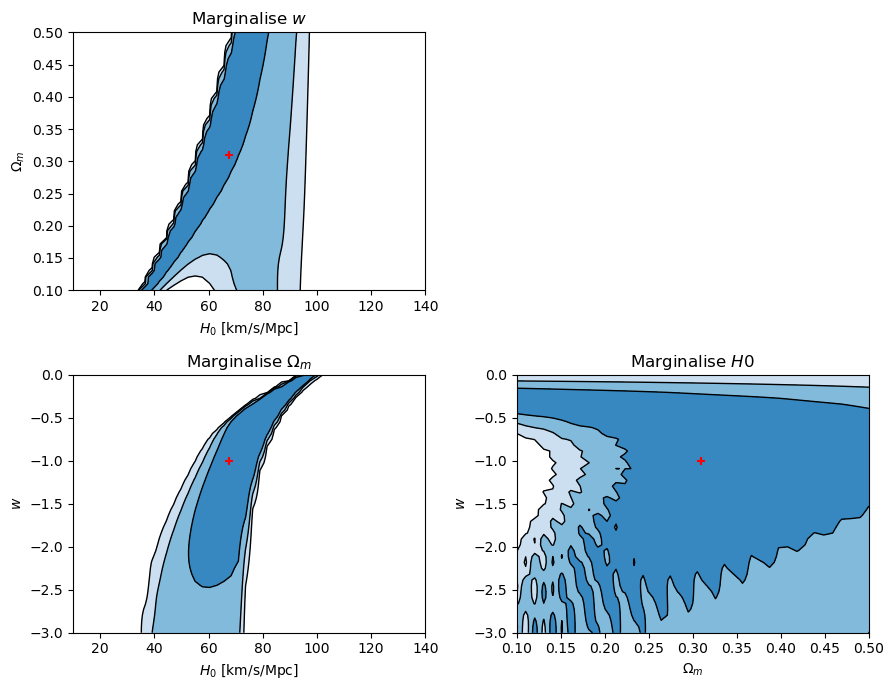

In [35]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)


ax1.contourf(H_Om, Om_H0, P2d_H0Om, levels=t_contours_H0Om, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, P2d_H0Om, levels=t_contours_H0Om, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_facecolor('1.0')
ax1.set_title(r'Marginalise $w$')


ax3.contourf(H_w, w_H, P2d_H0w.T, levels=t_contours_H0w, colors=[blues(2), blues(4), blues(6)], extend='max')
ax3.contour(H_w, w_H, P2d_H0w.T, levels=t_contours_H0w, colors="black", linewidths=1)
ax3.scatter(HUBBLE, W_LAMBDA, marker='+', c='r', zorder=10)
ax3.set_ylabel(r'$w$')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_facecolor('1.0')
ax3.set_title(r'Marginalise $\Omega_m$')


ax4.contourf(Om_w, w_Om, P2d_Omw.T, levels=t_contours_Omw, colors=[blues(2), blues(4), blues(6)], extend='max')
ax4.contour(Om_w, w_Om, P2d_Omw.T, levels=t_contours_Omw, colors="black", linewidths=1)
ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='r', zorder=10)
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel(r'$w$')
ax4.set_facecolor('1.0')
ax4.set_title(r'Marginalise $H0$')


plt.tight_layout()
plt.show()

---------------------------------------------------

# Distances with errors <a name="Uncertain_distance_info"></a>

Now take into account that distances can have errors. To calculate the cosmological parameters, we'll follow a Bayesian approach:

$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \pi(\mathbf{H_0}) \cdot P(d_L^{\rm obs}, {\rm DM}^{\rm obs}|\mathbf{H_0}) = \\
\int dz \ P\left(d_L^{\rm obs}|d_L(z,\mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) \cdot \pi(z)
$$
where with $\mathbf{H_0}$ we denote the _vector_ of cosmological parameters ($H_0, \Omega_m, w$) and $\pi(z)$ is the prior on the redshift distribution of sources and $\pi(\mathbf{H_0})$ the priors on the cosmological parameters. 

For the ${\rm DM}$ part, we can introduce the contributions of different sources as systematic errors and marginalise over them. In reality, we can estimate ${\rm DM}_{\rm IGM}$ as:

$$
{\rm DM}_{\rm IGM} = {\rm DM}^{\rm obs} - {\rm DM}^{\rm MW} - {\rm DM}^{\rm HG}/(1+z), 
$$

where ${\rm DM}^{\rm MW} = {\rm DM}^{\rm MW}_{\rm halo} + {\rm DM}^{\rm MW}_{\rm ISM}$. So we can write $P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right)$ as:

$$
P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) = \int d{\rm DM}^{\rm MW} d{\rm DM}^{\rm HG} \pi({\rm DM}^{\rm MW}) \pi({\rm DM}^{\rm HG}) P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}), {\rm DM}^{\rm MW}, {\rm DM}^{\rm HG} \right).
$$

Return to TOC [here](#toc).

### 1. **Simplified version**

Before analysing the problem in its full complexity, let's investigate a simplified version, where:

1. The prior on redshifts is flat (so we can ignore $\pi(z)$).
2. We are able to measure (as in the previous sections) directly ${\rm DM}_{\rm IGM}$, so we do not need to worry about the other contributions.
3. We keep the errors ($\sigma_{d_L}, \sigma_{{\rm DM}}$) fixed.

We then simply have:
$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \int dz \ P\left(d_L^{\rm obs}|d_L(z, \mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0})\right)\ ({\rm S*}).
$$

<div class="alert alert-block alert-danger">
<b>NB:</b> Extra things to consider: 
<br>
    - Selection effects?
</div>

### Simplified version: **1 event**

The steps we follow to create mock data are the following:

1. Choose (randomly) a redshift.
2. For the fiducial cosmology, calculate $d_L^{\rm obs}$ and ${\rm DM}^{\rm obs}$.
3. Add some scatter around the true values, by generating updated observed values through $d^{\rm obs}_{\rm L, new} = \mathcal{N}(d_L^{\rm obs}, \sigma_{d_L})$ and ${\rm DM}^{\rm obs}_{\rm new} = \mathcal{N}({\rm DM}^{\rm obs}, \sigma_{\rm DM})$.
4. Draw some samples around the new values, to recreate some realistic posteriors.

We then use these, to fit for the cosmological parameters (according to $({\rm S*})$).

**For FRB DM, try to use Macquart pdf**

$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$

$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

$ p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) $

$ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

$\Delta=DM_{cosmic}/<DM_{cosmic}>$

$ \sigma_{DM}=Fz^{-0.5} $

Which 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$ in Macquart paper.

Better to consider Surajit's likelihood 3 ([Surajit](https://arxiv.org/abs/2410.01974)) later. They also consider $DM_{halo}$ as a gaussian distribution

$$ DM_{halo}=\frac{1}{\sqrt{2\pi}\sigma_{halo}}\exp\left(-\frac{(DM_{halo}-\mu_{halo})^2}{2\sigma_{halo}^2}\right) $$

Take median value found in Macquart paper MCMC:

$F=0.31$, $\exp(\mu)=68.2$, $\sigma_{host}=0.88$, $\Omega_b h_{70}=0.056$. And $DM_{MW,halo}=50 pc/cm^3$

In [ ]:
F=0.31
exp_mu=68.2
sigma_host=0.88

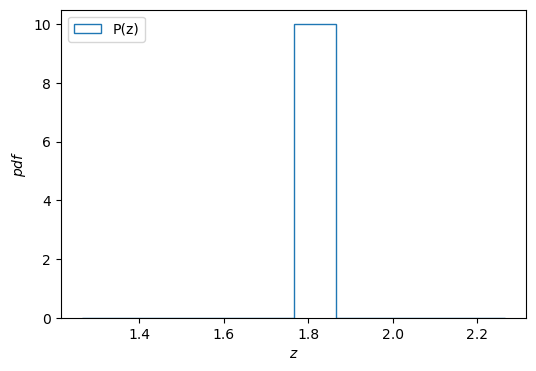

In [46]:
## Random choice of redshift
z_range = np.linspace(0.05, 2, 500)
z_centre = np.random.choice(z_range, size=1, replace=True,\
                            p=Distribution_redshift(z_range, HUBBLE, OMEGA_MATTER))

fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(z_center, density=True, histtype='step', label='P(z)')
# ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

In [47]:
z_centre=z_centre[0]
print(z_centre)

1.7108216432865733


In [58]:
# Theoretical dL, fiducial cosmo
cosmo_fid = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER)
dL_centre = cosmo_fid.luminosity_distance(z_centre).value

# Theoretical DM, fiducial cosmo
DM_centre = dispersion_measure(z_centre, H0=HUBBLE, Om=OMEGA_MATTER)
print(DM_centre)

1613.8827157802002


We create the distance posteriors, by moving around the central values and assuming observational errors.

In [68]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

## Choice of observed DM from p_IGM
# sigma_DM = 105
# DM_obs_centre = np.random.normal(DM_centre, sigma_DM)

delta = sample_delta(z_centre)
# s_DM_obs[idx] = DM_fid * f_sigma_DM(F=F, z=z_val) # May need to correct to the real function sigma. Not sure if DM_IGM in PDF is the sigma
DM_obs_centre = DM_centre * delta

print(DM_obs_centre)

1739.654390614359


In [55]:
## Creating the posteriors around the observed values

dL_gaussian = np.random.normal(dL_obs_centre, sigma_dL, 1000)

# no need, we have p_IGM already
# DM_gaussian = np.random.normal(DM_obs_centre, sigma_DM, 1000)
# print(DM_gaussian)

To avoid unphysical (negative) values for distances, we are going to set these to zero:

In [56]:
## Here we are imposing a hard cut
dL_gaussian[dL_gaussian<0]=0
# DM_gaussian[DM_gaussian<0]=0

In [57]:
## Fitting KDEs around the observed events
GW_dL_kde = gaussian_kde(dL_gaussian)
# no need fitting to find DM_kde, because we have p_IGM
# FRB_DM_kde = gaussian_kde(DM_gaussian)

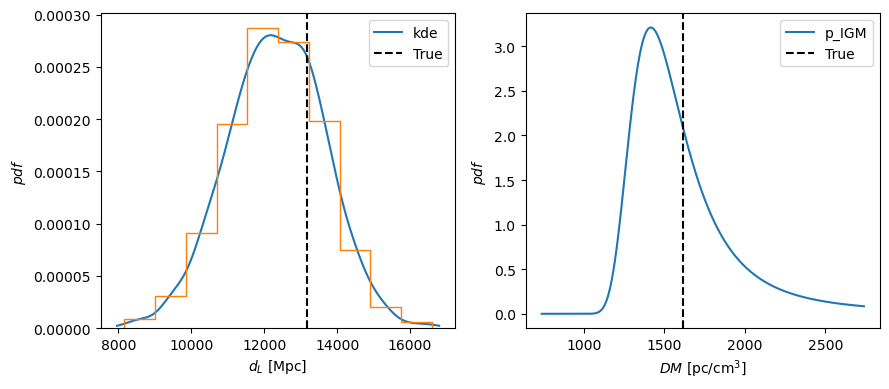

In [70]:
dl_array=np.linspace(np.min(dL_gaussian)-200, np.max(dL_gaussian)+200, 500)
# DM_array=np.linspace(np.min(DM_gaussian)-200, np.max(DM_gaussian)+200, 500)
DM_array=np.linspace(np.max([20,DM_obs_centre-1000]), DM_obs_centre+1000, 500)

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(dl_array, GW_dL_kde(dl_array), label='kde')
ax1.hist(dL_gaussian, density=True, histtype='step')
ax1.axvline(x=dL_centre, ls='--', c='black', label='True')
ax1.set_xlabel(r'$d_L$ [Mpc]')
ax1.set_ylabel(r'$pdf$')
ax1.legend()

vec_DM_cosmo=np.vectorize(pdf_DM_cosmo)

# ax2.plot(DM_array, FRB_DM_kde(DM_array), label='kde')
C_0 = find_C0(F=F, z=z_centre, sigmas=sigmas, C0s=C0s)
A = find_A(C_0=C_0, F=F, z=z_centre)
ax2.plot(DM_array, vec_DM_cosmo(Delta=DM_array/DM_obs_centre, C_0=C_0, A=A, sigma=f_sigma_DM(F,z_centre)), label='p_IGM')
# ax2.hist(DM_gaussian, density=True, histtype='step')
ax2.axvline(x=DM_centre, ls='--', c='black', label='True')
ax2.set_xlabel(r'$DM$ [pc/cm$^3$]')
ax2.set_ylabel(r'$pdf$')
ax2.legend()

plt.tight_layout()
plt.show()

We now create a redshift range capable of covering the full range of $d_L$ and ${\rm DM}$. In practice, this is our prior on redshifts (which can be quite agnostic).

In [81]:
## Redshift range
z_array=np.linspace(0.1, 3.0, 500)

## Luminosity distance and DM range for fiducial cosmology (for visualisation purposes)
## i.e. we are transforming our redshift range to distances and DMs
lum_distance = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_array).value

# DM_distance = []
# for z_val in z_array:
#     DM_distance.append(dispersion_measure(z_val, H0=HUBBLE, Om=OMEGA_MATTER))
    
# DM_distance = np.array(DM_distance)

In [82]:
# use DM_distance replace FRB_DM_kde
DM_distance = []
for z_val in z_array:
    C_0 = find_C0(F=F, z=z_val, sigmas=sigmas, C0s=C0s)
    A = find_A(C_0=C_0, F=F, z=z_val)
    DM_distance.append(pdf_DM_cosmo(Delta=dispersion_measure(z_val, H0=HUBBLE, Om=OMEGA_MATTER)/DM_obs_centre, C_0=C_0, A=A, sigma=f_sigma_DM(F,z_val)))
    
DM_distance = np.array(DM_distance)

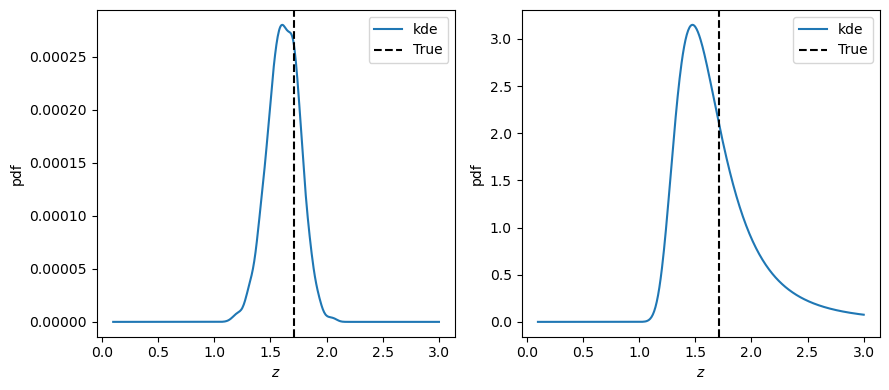

In [83]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_array, GW_dL_kde(lum_distance), label='kde')
ax1.axvline(x=z_centre, ls='--', c='black', label='True')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'pdf')
ax1.legend()


# ax2.plot(z_array, FRB_DM_kde(DM_distance), label='kde')
ax2.plot(z_array, DM_distance, label='kde')
ax2.axvline(x=z_centre, ls='--', c='black', label='True')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend()

plt.tight_layout()
plt.show()

**$H_0$ inference, assuming a fixed $\Omega_m$**. 

For a given $H_0$, we produce a distance and ${\rm DM}$ range (keeping $\Omega_m$ fixed). We weigh these by comparing to our observed pdfs for $d_L$ and ${\rm DM}$. Since these two observations were made independently, we multiply their LHDs, and marginalise (integrate) over redshift, i.e. we're calculating the formula $({\rm S*})$ above, to get $P(H_0)$. Finally, we normalize the $P(H_0)$ to get the cosmological constraints.

$$ P(H_0)=\int P(D_L|H_0,z)P(DM|H_0,z)dz $$

In [84]:
### These are our priors
H0_array = np.linspace(10, 140, 100)
Omega_m_array = np.linspace(0.1, 0.5, 60)
w_array = np.linspace(-3.0, 0.0, 65)

## For 2D case
H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

## For 3D case
H_3D, Om_3D, w_3D = np.meshgrid(H0_array, Omega_m_array, w_array)

## We vectorise dispersion measure (this is just a normal loop under the hood)
## Note that the arguments are (z, H0, Om, w) in the original function
vecDM = np.vectorize(dispersion_measure)
vecDL = np.vectorize(luminosity_distance)

$ H_0$ constraints:

In [87]:
posterior_normed = np.zeros_like(H0_array)

### For each H0 value, we calculate the integral
for i, H0 in enumerate(H0_array):
    
    ## The luminosity distance for given H0, for all z
    lum_distance = FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value
    
    # ## The DM for given H0, for all z
    # DM_distance=vecDM(z_array, H0=H0, Om=OMEGA_MATTER) 
   
    # ## Integrate out the redshift dependence
    # posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)
    
    p_DM=[]
    for z_val in z_array:
        C_0 = find_C0(F=F, z=z_val, sigmas=sigmas, C0s=C0s)
        A = find_A(C_0=C_0, F=F, z=z_val)
        p_DM.append(pdf_DM_cosmo(Delta=dispersion_measure(z_val, H0=H0, Om=OMEGA_MATTER)/DM_obs_centre, C_0=C_0, A=A, sigma=f_sigma_DM(F,z_val)))
    p_DM=np.array(p_DM)
        
    posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*p_DM, z_array)

## Normalise posterior
posterior_normed/=np.trapz(posterior_normed, H0_array)

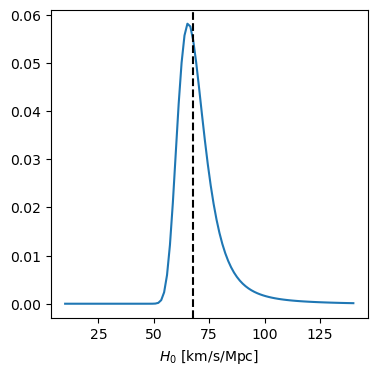

In [88]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()

Stop here, just modified for part 3 H0 constraint

**$H_0$ and $\Omega_m$ constraints**

We now perform the same exercise, but also vary $\Omega_m$.

**NB**: This takes quite a lot of time for a high-resolution grid.

In [16]:
z_array=np.linspace(0.1, 1.5, 100) ## We make this lower-res, because it creates a bottleneck

posterior_2D = np.zeros_like(H_Om)

### For each H0 value, we calculate the integral
for i, H0 in enumerate(H0_array):
    for j, Omega_m in enumerate(Omega_m_array):
        lum_distance = FlatLambdaCDM(H0=H0, Om0=Omega_m).luminosity_distance(z_array).value
        DM_distance = vecDM(z_array, H0=H0, Om=Omega_m)

        ## Integrate out the redshift dependence
        posterior_2D[j,i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)

### We normalise the posterior
total_p = np.sum(posterior_2D)
posterior_2D_normed = posterior_2D/total_p

Finding the percentages in the contour plots (as above):

In [17]:
## Calculate the contour levels (automate the procedure with a finction)
t_contours_post2D = posterior_contour_2D(posterior_2D_normed)

In [18]:
## These are already normalised (no need to normalise again, if we don't want to)

P_Om = normalise(np.sum(posterior_2D_normed, axis=1))
P_H0 = normalise(np.sum(posterior_2D_normed, axis=0))

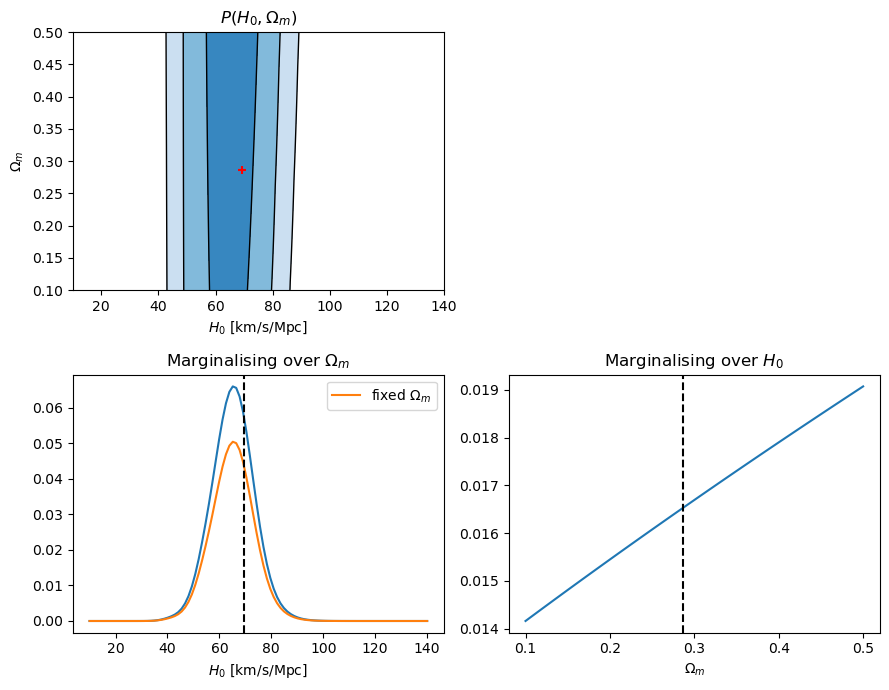

In [19]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, posterior_2D_normed, levels=t_contours_post2D, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, posterior_2D_normed, levels=t_contours_post2D, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$P(H_0, \Omega_m)$')

ax3.plot(H0_array, P_H0)
ax3.plot(H0_array, posterior_normed, label=r'fixed $\Omega_m$')
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_title(r'Marginalising over $\Omega_m$')
ax3.legend()

ax4.plot(Omega_m_array, P_Om)
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_title(r'Marginalising over $H_0$')

plt.tight_layout()
plt.show()

**$H_0, \Omega_m, w$ constraints**

We now run the full analysis, i.e. varying all the parameters

<div class="alert alert-block alert-danger">
<b>NB:</b> This is very slow - even for 1 event. Probably something like an MCMC would be needed.
</div>

In [24]:
### Redifne priors here to reduce resolution, to make code faster.
H0_array = np.linspace(10, 140, 80)
Omega_m_array = np.linspace(0.1, 0.5, 40)
w_array = np.linspace(-3.0, 0.0, 45)

## For 2D case
H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

## For 3D case
H_3D, Om_3D, w_3D = np.meshgrid(H0_array, Omega_m_array, w_array)

## We make this lower-res, because it creates a bottleneck (on top of the 3 variable inference)
z_array=np.linspace(0.1, 1.5, 80)

In [25]:
posterior_3D = np.zeros_like(H_3D)

for i, H0 in enumerate(H0_array):
    for j, Om0 in enumerate(Omega_m_array):
        for k, w0 in enumerate(w_array):
            
            lum_distance=vecDL(z = z_array, Om=Om0, H0=H0, w = w0)
            DM_distance=vecDM(z = z_array, Om=Om0, H0=H0, w = w0)
            
            posterior_3D[j, i, k] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)
        print([i,j],end='\r')
            
### We normalise the posterior
total_p = np.sum(posterior_3D)
posterior_3D_normed = posterior_3D/total_p

In [26]:
Post2d_H0w = normalise(np.sum(posterior_3D_normed, axis=0))
Post2d_Omw = normalise(np.sum(posterior_3D_normed, axis=1))
Post2d_OmH = normalise(np.sum(posterior_3D_normed, axis=2))

In [27]:
H0w_contour = posterior_contour_2D(Post2d_H0w)
Omw_contour = posterior_contour_2D(Post2d_Omw)
OmH_contour = posterior_contour_2D(Post2d_OmH)

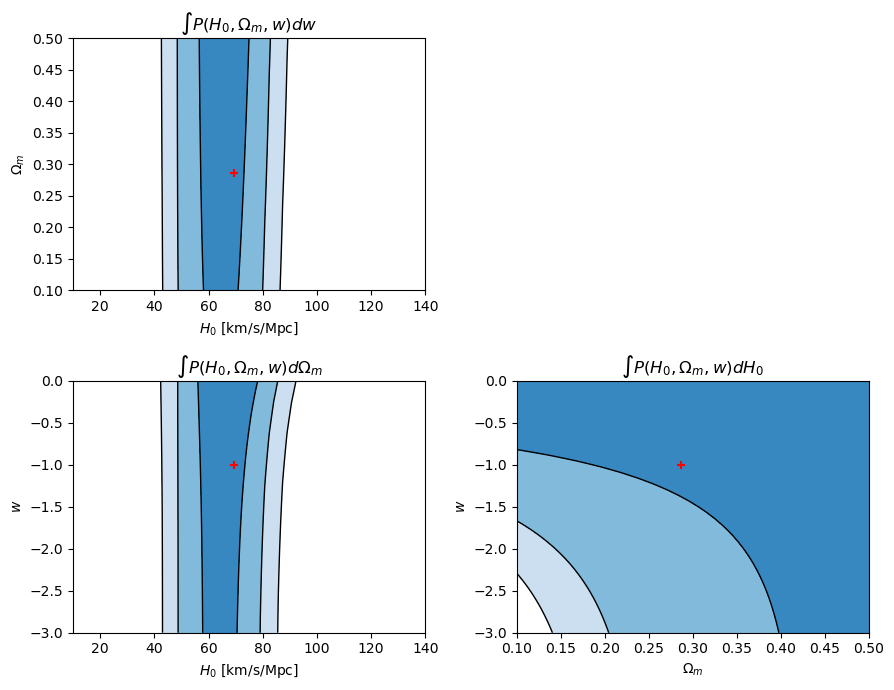

In [30]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, Post2d_OmH, levels=OmH_contour, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, Post2d_OmH, levels=OmH_contour, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$\int P(H_0, \Omega_m, w) dw$')

ax3.contourf(H_w, w_H, Post2d_H0w.T, levels=H0w_contour, colors=[blues(2), blues(4), blues(6)], extend='max')
ax3.contour(H_w, w_H, Post2d_H0w.T, levels=H0w_contour, colors="black", linewidths=1)
ax3.scatter(HUBBLE, W_LAMBDA, marker='+', c='r', zorder=10)
ax3.set_ylabel(r'$w$')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_title(r'$\int P(H_0, \Omega_m, w) d\Omega_m $')


ax4.contourf(Om_w, w_Om, Post2d_Omw.T, levels=Omw_contour, colors=[blues(2), blues(4), blues(6)], extend='max')
ax4.contour(Om_w, w_Om, Post2d_Omw.T, levels=Omw_contour, colors="black", linewidths=1)
ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='r', zorder=10)
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel(r'$w$')
ax4.set_title(r'$\int P(H_0, \Omega_m, w) dH_0 $')

plt.tight_layout()
plt.show()

### **Multiple events**

Extend the analysis above to multiple events

In [145]:
## Random choice of redshifts
zs_centre = np.random.choice(np.linspace(0.5, 1.5, 20), size=5)

## Luminosity distance
dL_centres = cosmo_fid.luminosity_distance(zs_centre).value

## DM measure
DM_centres=vecDM(zs_centre, Om=OMEGA_MATTER, H0=HUBBLE)

In [146]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centres

## Choice of observed DM
sigma_DM = 105

dL_obs_centres = np.zeros_like(zs_centre)
DM_obs_centres = np.zeros_like(zs_centre)

for idx, dL in enumerate(dL_centres):
    dL_obs_centres[idx] = np.random.normal(dL, sigma_dL[idx])
    DM_obs_centres[idx] = np.random.normal(DM_centres[idx], sigma_DM)

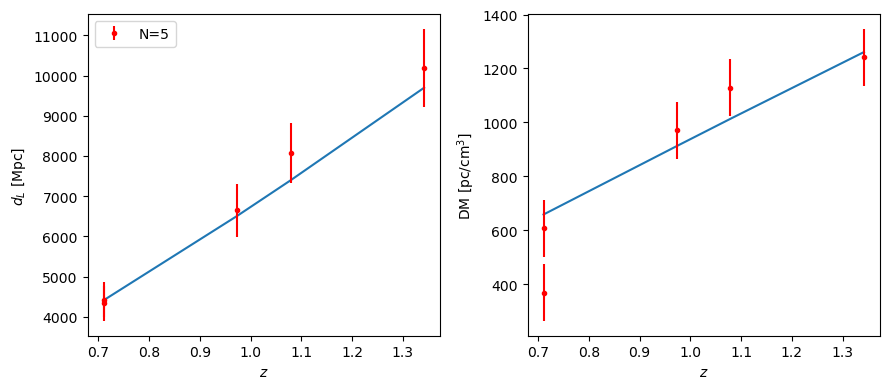

In [147]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(zs_centre), np.sort(dL_centres))
ax1.errorbar(zs_centre, dL_obs_centres, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(zs_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(zs_centre), np.sort(DM_centres))
ax2.errorbar(zs_centre, DM_obs_centres, yerr=sigma_DM, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

In [148]:
posterior_normed = np.zeros_like(H0_array)
posterior_normed_all = np.ones_like(H0_array)

for idx, dL in enumerate(dL_obs_centres):
    dL_gaussian = np.random.normal(dL, sigma_dL[idx], 1000)
    DM_gaussian = np.random.normal(DM_obs_centres[idx], sigma_DM, 1000)
    
    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
    FRB_DM_kde = gaussian_kde(DM_gaussian)
    
    for i, H0 in enumerate(H0_array):
        lum_distance=FlatLambdaCDM(H0=H0, Om0=OMEGA_MATTER).luminosity_distance(z_array).value
        
        DM_distance = []
        for z_val in z_array:
            DM_distance.append(dispersion_measure(z_val, Om=OMEGA_MATTER, H0=H0))

        DM_distance = np.array(DM_distance)
        
        posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)
        
    posterior_normed/=np.trapz(posterior_normed, H0_array)
    
    posterior_normed_all=posterior_normed_all*posterior_normed

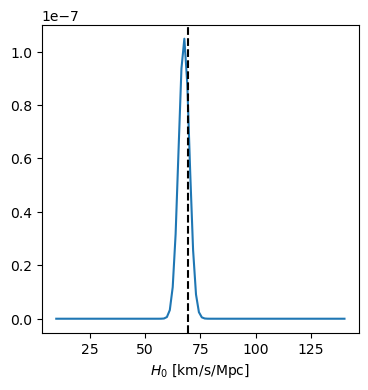

In [149]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed_all, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()

**$H_0$ and $\Omega_m$ constraints**

In [150]:
posterior_2D = np.zeros_like(H_Om)
posterior_2D_all = np.ones_like(H_Om)

for idx, dL in enumerate(dL_obs_centres):
    dL_gaussian = np.random.normal(dL, sigma_dL[idx], 1000)
    DM_gaussian = np.random.normal(DM_obs_centres[idx], sigma_DM, 1000)
    
    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
    FRB_DM_kde = gaussian_kde(DM_gaussian)
    
    for i, H0 in enumerate(H0_array):
        for j, Om in enumerate(Omega_m_array):
            lum_distance=FlatLambdaCDM(H0=H0, Om0=Om).luminosity_distance(z_array).value
            DM_distance = vecDM(z_array, H0=H0, Om=Om)

            posterior_2D[j,i] = np.trapz(GW_dL_kde(lum_distance)*FRB_DM_kde(DM_distance), z_array)
        
    posterior_2D=normalise(posterior_2D)
    posterior_2D_all=posterior_2D_all*posterior_2D

posterior_2D_all=normalise(posterior_2D_all)

In [151]:
t_contours_post2D = posterior_contour_2D(posterior_2D_all)
P_Om = normalise(np.sum(posterior_2D_all, axis=1))
P_H0 = normalise(np.sum(posterior_2D_all, axis=0))

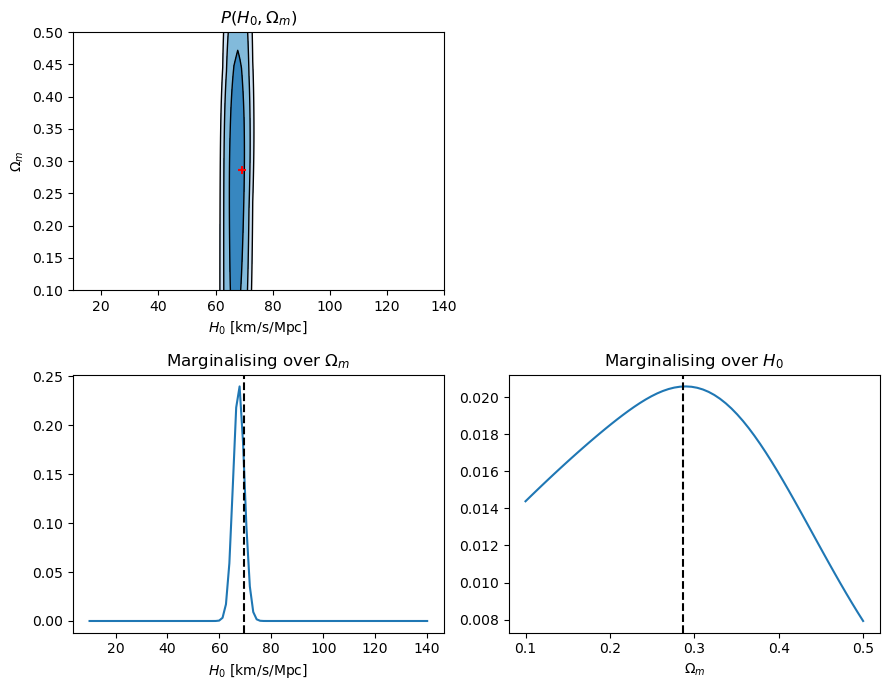

In [154]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, posterior_2D_all, levels=t_contours_post2D, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, posterior_2D_all, levels=t_contours_post2D, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$P(H_0, \Omega_m)$')

ax3.plot(H0_array, P_H0)
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(fr'$H_0$ [km/s/Mpc]')
ax3.set_title(r'Marginalising over $\Omega_m$')

ax4.plot(Omega_m_array, P_Om)
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_title(r'Marginalising over $H_0$')

plt.tight_layout()
plt.show()

-----------------------------------------

# *Finding the missing baryons* <a name="Macquart_paper"></a>

We replicate the analysis of [[Macquart et al](https://www.nature.com/articles/s41586-020-2300-2)]. This uses only FRB observations to set some cosmological constraints, **assuming precise redshifts** for FRBs.

However, it offers some suggestions for the *pdf* of ${\rm DM}_{\rm host}$ and ${\rm DM}_{\rm cosmic/IGM}$, that we want to use in our analysis.

Return to TOC [here](#toc).

In [31]:
def pdf_DM_host(DM, e_mu, sigma_host, z):
    # e^\mu with 20-200 pc cm^{-3} and \sigma_{host} in 0.2-2.0
    mu=np.log(e_mu)
    DM_h = DM/(1+z) ## TO CROSS-CHECK THIS
    
    pdf=np.exp(-(np.log(DM)-mu)**2/(2*sigma_host**2))/(sigma_host*np.sqrt(2*np.pi)*DM)
    
    return pdf


######################################################################################

def dDM_integrand_w(z, Om, w):
    """
    Function of the integrand of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    """
    return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))


def DM_cosmic(z, H0Ob, Om, w=-1):
    """
    Function of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    7/8 comes from (1-Y_He/2)
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    DM : Dispersion measure [pc/cm^3]
    """    

    factor = 3*C_LIGHT*(H0Ob*KM_2_MPC)*f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

def pdf_DM_cosmo(DM, F, z, H0Ob, Om, w=-1, alpha=3):
    beta= alpha
    sigma_DM=F/z**(0.5)

    DM_c = DM_cosmic(z, H0Ob, Om, w=-1)
    Delta = DM/DM_c
    
    pdf=Delta**(-beta)*np.exp(-(Delta**(-alpha)-C_0)**2/(2*alpha**2*sigma_DM**2))
    
    return pdf

-----------------------------------------------------

# Appendix

## A1 - Checking cosmological functions <a name="AP_Cosmo_functions"></a>

Return to TOC [here](#toc).

1. Reproduce Figure 2 of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)], to check our definitions of luminosity distance and dispersion measure.

In [54]:
z_range = np.linspace(0.2, 2.0, 50)

dL_values_astropy = FlatLambdaCDM(H0=HUBBLE, Om0=OMEGA_MATTER).luminosity_distance(z_range).value

dL_values = np.zeros_like(z_range)
DM_values = np.zeros_like(z_range)

for idx, z_val in enumerate(z_range): 
    dL_values[idx] = luminosity_distance(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    DM_values[idx] = dispersion_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)

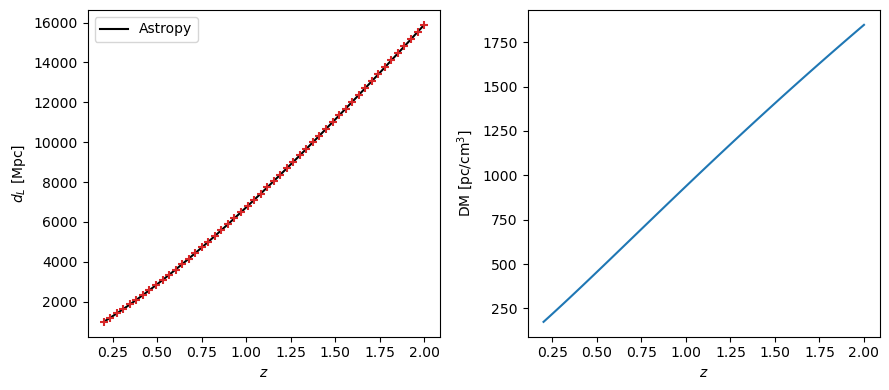

In [55]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_range, dL_values_astropy, ls='-', c='black', label='Astropy')
ax1.scatter(z_range, dL_values, s=35, marker='+', c='tab:red', zorder=10)
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend()

ax2.plot(z_range, DM_values)
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

2. Check that `dLDM_measure` is the same as $dL \cdot {\rm DM}$. Normalise wrt Einstein-deSitter (EdS) Universe, i.e. $\Omega_m = 1$, to compare with FIgure 1 (right), pink line of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [55]:
dLDM_theory = dL_values*DM_values
dLDM_values = np.zeros_like(z_range)
dLDM_values_EdS = np.zeros_like(z_range)


for idx, z_val in enumerate(z_range): 
    dLDM_values[idx] = dLDM_measure(z_val, HUBBLE, OMEGA_MATTER, w=-1)
    dLDM_values_EdS[idx] = dLDM_measure(z_val, HUBBLE, Om=1, w=-1)    

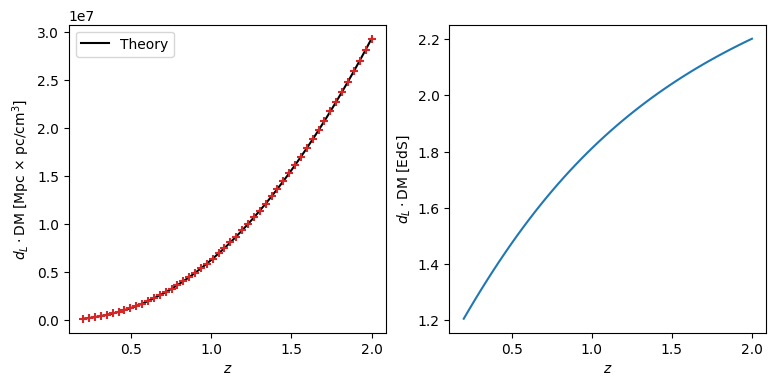

In [56]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)


ax1.plot(z_range, dLDM_theory, ls='-', c='black', label='Theory')
ax1.scatter(z_range, dLDM_values, s=35, marker='+', c='tab:red', zorder=10)
ax1.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [Mpc $\times$ pc/cm$^3$]')
ax1.set_xlabel(r'$z$')
ax1.legend()

ax2.plot(z_range, dLDM_values/dLDM_values_EdS)
ax2.set_ylabel(r'$d_{L} \cdot {\rm DM}$ [EdS]')
ax2.set_xlabel(r'$z$')

plt.show()

## A2 - Interpolating DM measure <a name="AP_Interpolate_DM"></a>

We want to create an interpolant of:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}},
$$

for the redshift range $0.01<z<2$ (avoid zero for divergences), to speed up our inference model. For this reason, we are going to use an array of $H_0$ and $\Omega_m$ values, and fix $w=-1$. We keep the redshift integration range fixed.


Return to TOC [here](#toc).

In [65]:
from scipy.interpolate import RegularGridInterpolator

In [61]:
## Sparse grid
H0_array = np.linspace(10, 140, 20)
Omega_m_array = np.linspace(0.1, 0.5, 20)
z_array = np.linspace(0.1, 1.5, 20)

xg, yg ,zg = np.meshgrid(H0_array, Omega_m_array, z_array, indexing='ij')

DM_gridded = np.zeros_like(xg)

In [62]:
DM_gridded.shape

(20, 20, 20)

In [63]:
for i, H0 in enumerate(H0_array):
    for j, Omega_m in enumerate(Omega_m_array):
        for k, z in enumerate(z_array):
        
            DM_gridded[k, j, i] = dispersion_measure(z, H0, Omega_m)

In [66]:
interp = RegularGridInterpolator((H0_array, Omega_m_array, z_array), DM_gridded)

In [69]:
## Fine grid
H0_array = np.linspace(10, 140, 40)
Omega_m_array = np.linspace(0.1, 0.5, 40)
z_array = np.linspace(0.1, 1.5, 40)

xg, yg ,zg = np.meshgrid(H0_array, Omega_m_array, z_array, indexing='ij')

DM_fine = np.zeros_like(xg)

In [71]:
for i, H0 in enumerate(H0_array):
    for j, Omega_m in enumerate(Omega_m_array):
        for k, z in enumerate(z_array):
        
            DM_fine[k, j, i] = dispersion_measure(z, H0, Omega_m)

In [98]:
interpolated_values = interp((xg, yg, zg), method='linear')

In [99]:
Delta_interpolation = ((DM_fine-interpolated_values)/DM_fine*100).ravel()

In [100]:
np.max(Delta_interpolation)

52.87422841740388

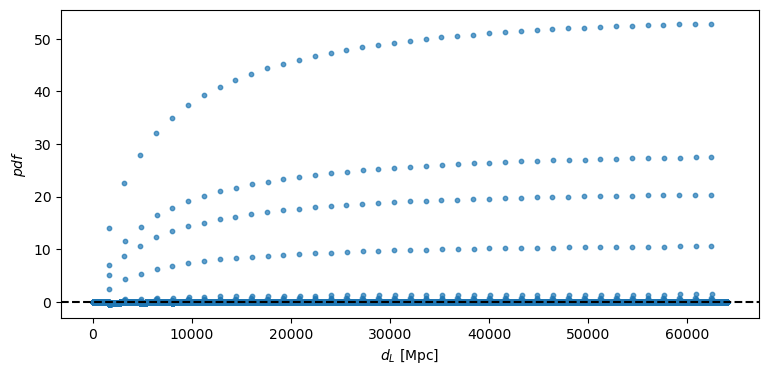

In [106]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(111)

ax1.scatter(np.arange(Delta_interpolation.size), Delta_interpolation, s=10, alpha=0.7)
ax1.axhline(y=0, ls='--', c='black', label='True')
ax1.set_xlabel(r'$d_L$ [Mpc]')
ax1.set_ylabel(r'$pdf$')

plt.show()

<div class="alert alert-block alert-warning">
<b>Comment:</b> DM interpolator not very precise (errors up to 50%). For a realistic speed-up and more precise inference, probably best to use MCMC methods. 
</div>